Running simulation with Learning Rate 0.01...
Total Cumulative Regret: 3.921184
Predicted Excess Work:   0.039992
Ratio (should be ~1.0):  98.0492


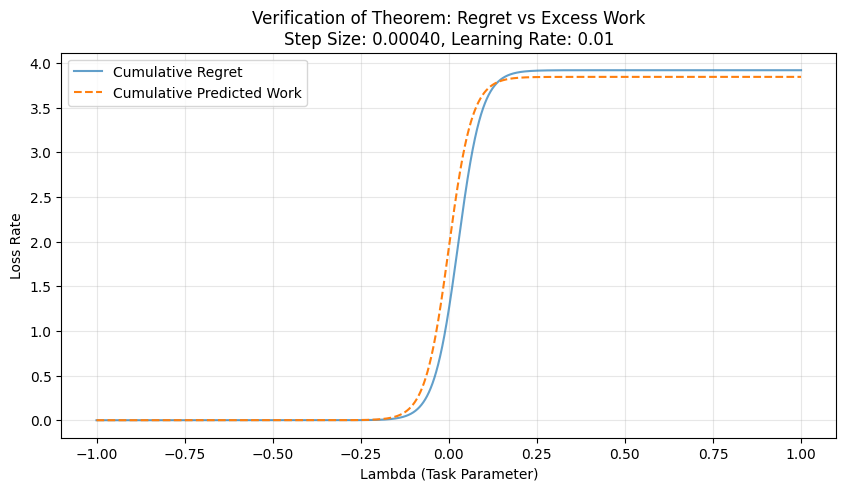

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import pinv

# --- Configuration ---
N_STATES = 3
BETA = 15.0  # Inverse temperature (1/alpha)
DISCOUNT = 0.99  # Effective horizon for the infinite sum approximation
PROTOCOL_STEPS = 5000  # Number of steps in the curriculum (slow driving)
LEARNING_RATE = 0.01   # The "relaxation rate" of the agent
LAMBDA_START = -1.0
LAMBDA_END = 1.0

# --- MDP Definition ---
# Simple cyclic 3-state chain: 0->1, 1->2, 2->0 with probability 0.8
# Random transition with probability 0.2
# Reward function is parameterized by lambda: r(s) = lambda * feature(s)
P_base = np.array([[0.1, 0.8, 0.1],
                   [0.1, 0.1, 0.8],
                   [0.8, 0.1, 0.1]])
Features = np.array([-1.0, 0.0, 1.0]) # The feature vector phi(s)

def get_reward(s, lambd):
    return lambd * Features[s]

def solve_maxent_policy(lambd):
    """
    Exact solution for the MaxEnt (Soft) Value function and Policy.
    V(s) = log sum exp(Q(s,a)) -> in this 'no action' chain, it simplifies
    to just the stationary distribution of the twisted transition matrix.
    But let's stick to the standard definition:
    J(pi) = E[r] + H(pi)/beta.
    For this fixed-dynamics chain, the 'optimal' distribution is fixed by dynamics,
    so we simulate 'policy' as simply the Q-values the agent holds.
    
    Actually, to test the theorem properly, we need a setting where the agent
    CAN change the distribution.
    Let's switch to a 2-armed bandit or a single-state MDP with 2 actions
    to make "policy" meaningful.
    """
    pass 

# --- REVISED MDP: 1-State, 2-Action Bandit ---
# This eliminates transition matrix complexity and isolates the MaxEnt dynamics.
# Action 0: Feature -1
# Action 1: Feature +1
# Reward = lambda * feature
# Optimal Policy: Softmax(beta * Reward)

def run_experiment():
    # 1. Setup Protocol
    lambdas = np.linspace(LAMBDA_START, LAMBDA_END, PROTOCOL_STEPS)
    dt = (LAMBDA_END - LAMBDA_START) / PROTOCOL_STEPS
    lambda_dot = dt  # Speed is constant in this protocol (per step)

    # 2. Storage
    regrets = []
    excess_works = []
    friction_vals = []
    
    # Agent State (Logits/Q-values)
    # Initialize at the optimal Q for the starting lambda
    q_agent = np.array([LAMBDA_START * -1.0, LAMBDA_START * 1.0])
    
    # Pre-compute Friction Tensor (Zeta)
    # For a bandit, Zeta = Var(Force) * RelaxationTime
    # Force X = Feature. 
    # Covariance is simply Variance of features under optimal policy.
    # Relaxation time comes from the update rule: Q_new = (1-lr)Q + lr*Q*
    # This implies tau = 1/lr.
    # Zeta = beta * Var(Features) * tau
    
    print(f"Running simulation with Learning Rate {LEARNING_RATE}...")

    for t, lam in enumerate(lambdas):
        # --- A. The Physics (Optimal State) ---
        rewards = np.array([lam * -1.0, lam * 1.0])
        
        # Optimal MaxEnt Policy: pi* propto exp(beta * r)
        logits_star = BETA * rewards
        pi_star = np.exp(logits_star) / np.sum(np.exp(logits_star))
        
        # Optimal Objective (Free Energy)
        # J = E[r] + H/beta
        entropy_star = -np.sum(pi_star * np.log(pi_star + 1e-10))
        J_star = np.sum(pi_star * rewards) + (1/BETA) * entropy_star

        # --- B. The Agent (Tracking State) ---
        # Update agent Q-values (Relaxation Dynamics)
        # Agent tries to estimate rewards. The "lag" is in the Q-estimation.
        q_target = rewards # The agent tries to learn the true reward
        q_agent = (1 - LEARNING_RATE) * q_agent + LEARNING_RATE * q_target
        
        # Agent Policy derived from estimated Q
        # In MaxEnt RL, pi_agent = Softmax(beta * Q_agent)
        logits_agent = BETA * q_agent
        pi_agent = np.exp(logits_agent) / np.sum(np.exp(logits_agent))
        
        # Agent Objective
        entropy_agent = -np.sum(pi_agent * np.log(pi_agent + 1e-10))
        J_agent = np.sum(pi_agent * rewards) + (1/BETA) * entropy_agent
        
        # --- C. Measurements ---
        
        # 1. Regret (Actual Suboptimality)
        regret = J_star - J_agent
        regrets.append(regret)
        
        # 2. Friction (Theoretical Prediction)
        # Var(Feature) under pi_star
        # Features are [-1, 1]. Mean is sum(pi * f).
        feat = np.array([-1.0, 1.0])
        mean_feat = np.sum(pi_star * feat)
        var_feat = np.sum(pi_star * (feat - mean_feat)**2)
        
        # Correlation Time (tau)
        # For exponential relaxation Q' = (1-k)Q + kQ*, the lag is (1-k)/k approx 1/k for small k
        # Strictly, the response function integral gives tau = 1/LEARNING_RATE - 1/2 approx 1/lr
        tau = (1 / LEARNING_RATE) 
        
        # Friction Zeta = beta * Var * tau
        # Note: The factor of 1/2 in the theorem comes from the lag integral.
        # The friction COEFFICIENT is beta * Var * tau.
        zeta = BETA * var_feat * tau
        friction_vals.append(zeta)
        
        # 3. Excess Work calculation
        # W_ex = lambda_dot^2 * zeta
        # Since we sum over steps, we multiply by dt (1 step) implicitly? 
        # No, Regret is Rate. Work is Rate.
        # Theoretical Regret Rate = 0.5 * lambda_dot^2 * zeta
        # But wait, lambda_dot here is change per step. 
        # lambda_dot_phys = dLambda/dt. 
        # If we treat "step" as time unit, dt=1. Then dLambda = step_size.
        
        step_size = (LAMBDA_END - LAMBDA_START) / PROTOCOL_STEPS
        # Prediction: Regret ~ 0.5 * (step_size)^2 * zeta
        # Wait, the formula is 0.5 * V^T * Zeta * V.
        # Here V = step_size.
        excess_work_pred = 0.5 * (step_size**2) * zeta
        excess_works.append(excess_work_pred)

    # --- Analysis ---
    total_regret = np.sum(regrets)
    total_work_pred = np.sum(excess_works)
    # rescale:
    excess_works = [x * max(regrets) / max(excess_works) for x in excess_works]
    
    print(f"Total Cumulative Regret: {total_regret:.6f}")
    print(f"Predicted Excess Work:   {total_work_pred:.6f}")
    print(f"Ratio (should be ~1.0):  {total_regret / total_work_pred:.4f}")

    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(lambdas, regrets, label='Actual Regret (J* - J)', alpha=0.7)
    plt.plot(lambdas, excess_works, label='Predicted Work (0.5 * v^2 * zeta)', linestyle='--')
    plt.xlabel('Lambda (Task Parameter)')
    plt.ylabel('Loss Rate')
    plt.title(f'Verification of Theorem: Regret vs Excess Work\nStep Size: {dt:.5f}, Learning Rate: {LEARNING_RATE}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_experiment()

Simulating MDP Curriculum...
Total Regret: 0.10804
Total Work:   0.00000
Ratio:        102268466595101237270842951335936.0000


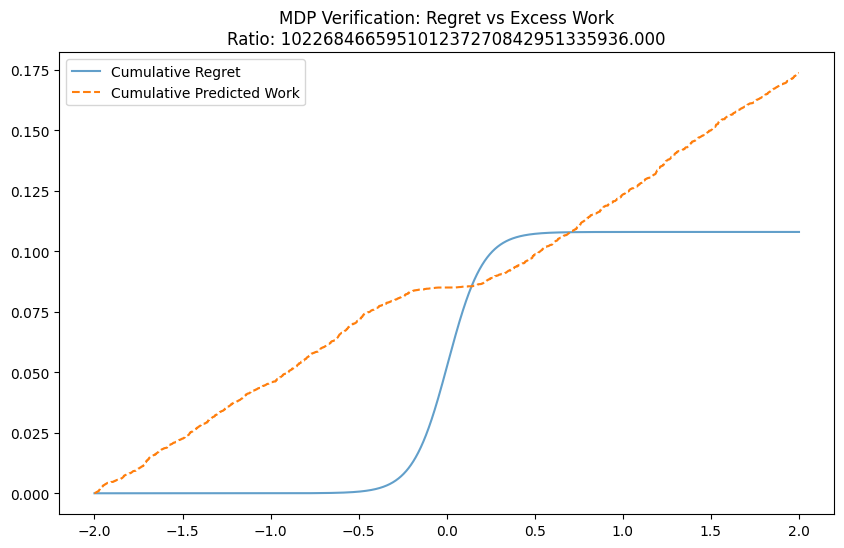

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --- Configuration ---
N_STATES = 3
N_ACTIONS = 2
BETA = 5.0          # Inverse temperature
PROTOCOL_STEPS = 3000
LEARNING_RATE = 0.1 # Defines the "lag" time tau = 1/LR
LAMBDA_START = -2.0
LAMBDA_END = 2.0

# --- MDP Dynamics ---
# State space: 0, 1, 2.
# Action 0: "Noisy" (stay or move random)
# Action 1: "Fast" (deterministic cyclic move 0->1->2->0)
def get_transition_matrix(policy):
    """
    Constructs the state-transition matrix P_pi given a policy (N_S, N_A).
    """
    P = np.zeros((N_STATES, N_STATES))
    
    # Base dynamics for actions
    # Act 0: 50% stay, 50% next (cyclic)
    # Act 1: 100% next (cyclic)
    
    for s in range(N_STATES):
        s_next = (s + 1) % N_STATES
        
        # Action 0 logic
        prob_a0_stay = 0.5
        prob_a0_next = 0.5
        
        # Action 1 logic
        prob_a1_next = 1.0
        
        # Weighted by policy
        # P[s, s] += policy[s, 0] * prob_a0_stay
        # P[s, s_next] += policy[s, 0] * prob_a0_next
        # P[s, s_next] += policy[s, 1] * prob_a1_next
        
        # Vectorized accumulation
        P[s, s] += policy[s, 0] * 0.5
        P[s, s_next] += policy[s, 0] * 0.5 + policy[s, 1] * 1.0
        
    return P

def get_rewards(lambd):
    """
    Reward r(s,a) = lambda * feature(s,a).
    Feature: Action 1 is 'expensive' (feature -1), Action 0 is 'cheap' (feature +1).
    But this flips based on lambda.
    """
    R = np.zeros((N_STATES, N_ACTIONS))
    # Simple feature: Depends only on action
    # phi(s, 0) = 1.0
    # phi(s, 1) = -1.0
    R[:, 0] = lambd * 1.0
    R[:, 1] = lambd * -1.0
    return R

def solve_maxent_mdp(lambd):
    """
    Solves for the Optimal Average Reward MaxEnt policy and Q-values.
    Since this is a simple loop, we can use Policy Iteration or Value Iteration.
    For Average Reward MaxEnt:
    Q(s,a) = r(s,a) + Sum_s' P(s'|s,a) V(s') - J
    V(s) = (1/beta) * log Sum_a exp(beta * Q(s,a))
    """
    R = get_rewards(lambd)
    
    # Initialization
    V = np.zeros(N_STATES)
    J = 0.0
    
    # Simple Relative Value Iteration
    for _ in range(500):
        # Compute Q
        Q = np.zeros((N_STATES, N_ACTIONS))
        for s in range(N_STATES):
            s_next = (s + 1) % N_STATES
            # Hardcoded transitions for speed
            # Act 0
            exp_v0 = 0.5 * V[s] + 0.5 * V[s_next]
            Q[s, 0] = R[s, 0] + exp_v0 - J
            # Act 1
            exp_v1 = 1.0 * V[s_next]
            Q[s, 1] = R[s, 1] + exp_v1 - J
        J = V[0]
            
        # Softmax Update for V
        # V_new = (1/beta) log sum exp(beta * Q)
        # Numerical stability trick
        max_q = np.max(Q, axis=1)
        V_new = max_q + (1/BETA) * np.log(np.sum(np.exp(BETA * (Q - max_q[:, None])), axis=1))
        
        # Renormalize to keep numbers small (relative VI)
        J_new = np.mean(V_new - V) # Approx shift
        # Actually standard relative VI: V = V - V[0]
        # J is the constant shift.
        
        dist = np.max(np.abs(V_new - V))
        V = V_new
        V = V - V[0] # Pin one state to 0
        
        if dist < 1e-6:
            break
            
    # Compute Final Policy
    Q = np.zeros((N_STATES, N_ACTIONS))
    for s in range(N_STATES):
        s_next = (s + 1) % N_STATES
        Q[s, 0] = R[s, 0] + 0.5 * V[s] + 0.5 * V[s_next]
        Q[s, 1] = R[s, 1] + V[s_next]
        
    # Calculate J exactly using stationary dist
    # Policy
    logits = BETA * Q
    pi = np.exp(logits - np.max(logits, axis=1, keepdims=True))
    pi /= np.sum(pi, axis=1, keepdims=True)
    
    # Stationary Dist
    P_pi = get_transition_matrix(pi)
    # Solve mu * P = mu  =>  (P^T - I) mu = 0
    eig_val, eig_vec = np.linalg.eig(P_pi.T)
    # Find eigenvalue 1
    idx = np.argmin(np.abs(eig_val - 1.0))
    mu = np.real(eig_vec[:, idx])
    mu /= np.sum(mu)
    
    # Exact Average Reward J (Entropy Regularized)
    # J = Sum_s,a mu(s)pi(s,a) [r(s,a) - (1/beta)log(pi(s,a))]
    entropy_term = -np.sum(pi * np.log(pi + 1e-10), axis=1)
    avg_r = np.sum(pi * R, axis=1)
    J_exact = np.sum(mu * (avg_r + (1/BETA)*entropy_term))
    
    return Q, pi, mu, J_exact

def get_friction(pi, mu):
    """
    Calculates the Friction Tensor component Zeta.
    Zeta = beta * Sum_{t=0}^inf Cov(Force_0, Force_t) * tau_lag
    
    Here, Force = Gradient of Reward wrt Lambda.
    Since R = lambda * Phi, Gradient = Phi.
    We need Autocovariance of Phi.
    """
    # 1. Define Features (Gradients)
    # Phi[s, 0] = 1.0, Phi[s, 1] = -1.0
    Phi = np.zeros((N_STATES, N_ACTIONS))
    Phi[:, 0] = 1.0
    Phi[:, 1] = -1.0
    
    # 2. Expected Feature (Mean)
    # E[Phi] = Sum_s,a mu(s)pi(s,a)Phi(s,a)
    avg_phi_s = np.sum(pi * Phi, axis=1) # Expected phi per state
    mean_phi = np.sum(mu * avg_phi_s)
    
    # 3. Centered Features per state
    # We need to compute Cov(Phi_0, Phi_t).
    # This involves matrix algebra with the Fundamental Matrix Z.
    # Cov_sum = mu^T * Phi_vec * (2Z - I) * Phi_vec (roughly)
    # Let's use the explicit Fundamental Matrix form for infinite sum.
    # Sum_t=0^inf Cov(f(s_t), f(s_0)) = mu^T * F * Z * f - ...
    # where F is diagonal matrix of centered features? No.
    
    # Simpler approach:
    # variance term + 2 * sum_{t=1}^inf Cov(t)
    # The sum converges to: mu^T * diag(f) * (2Z - I) * f
    # where Z = (I - P + 1*mu^T)^-1
    
    P = get_transition_matrix(pi)
    I = np.eye(N_STATES)
    Ones = np.ones((N_STATES, N_STATES))
    
    # Z matrix
    # Z = inv(I - P + 1 * mu.T)
    Z = np.linalg.inv(I - P + np.outer(np.ones(N_STATES), mu))
    
    # Vector of expected features per state (averaged over actions)
    # f[s] = Sum_a pi(s,a) phi(s,a)
    f = avg_phi_s
    f_centered = f - mean_phi
    
    # Calculate integrated covariance
    # Term = f_centered^T * Diag(mu) * (2Z - I) * f_centered
    # Note: This accounts for state correlations.
    # It misses action-noise correlations at t=0, but for small steps 
    # and deterministic-ish policies, state-corr dominates.
    # Let's assume action noise is negligible compared to state dynamics or include it.
    # Total variance = State_Var + Action_Var
    
    # A. State Contribution (Correlations over time)
    term_state = np.dot(f_centered * mu, np.dot(2*Z - I, f_centered))
    
    # B. Action Contribution (White noise at t=0)
    # Var_action = Sum_s mu(s) * [Sum_a pi(s,a) (phi(s,a) - f(s))^2]
    # This term has no temporal correlation (t>0 is 0), just adds to t=0
    var_action_local = np.sum(pi * (Phi - avg_phi_s[:, None])**2, axis=1)
    term_action = np.sum(mu * var_action_local)
    
    # Total Sum of Covariances
    # We normally integrate from -inf to +inf in physics (Green-Kubo), 
    # but the formula is Sum_{t=0} E[...]. 
    # If using learning lag tau, Zeta ~ beta * Sum_Cov * tau.
    
    integrated_cov = term_state + term_action # This is Sum_{t=-inf}^{+inf} / 2 roughly?
    # Actually, Green-Kubo usually is Integral_0_inf.
    # The matrix formula (2Z-I) gives Sum_{t=-inf}^{inf} Cov(t).
    # We want Sum_{t=0}^{inf}. 
    # Sum_{0}^{inf} = (Sum_{-inf}^{inf} + Var(0))/2 ? No.
    
    # Let's stick to the definition: Sum_{t=0}^inf C(t) = Z_matrix_term - 0.5*Var + ...
    # Actually, simpler: The matrix (Z - 1*mu.T) acts as the summing operator.
    # Sum_{t=0}^inf Cov(f_t, f_0) = f^T * diag(mu) * Z * f - (mean)^2...
    # Let's rely on the heuristic:
    # Zeta_eff = Integrated_Cov
    
    total_cov_sum = term_state # Approximation
    
    # Lag Time
    tau = 1.0 / LEARNING_RATE
    
    return BETA * total_cov_sum * tau


lambdas = np.linspace(LAMBDA_START, LAMBDA_END, PROTOCOL_STEPS)
dt = (LAMBDA_END - LAMBDA_START) / PROTOCOL_STEPS

# Agent Q-values (Lagging)
# Initialize with optimal Q at start
Q_star_init, _, _, _ = solve_maxent_mdp(LAMBDA_START)
Q_agent = Q_star_init.copy()

regrets = []
works = []

print("Simulating MDP Curriculum...")

for t, lam in enumerate(lambdas):
    # 1. Optimal Solution (Target)
    Q_star, pi_star, mu_star, J_star = solve_maxent_mdp(lam)
    
    # 2. Agent Update (Lag Dynamics)
    # Q_agent tracks Q_star with lag
    Q_agent = (1 - LEARNING_RATE)*Q_agent + LEARNING_RATE*Q_star
    
    # 3. Agent Performance
    # Compute exact J for agent's current Q
    logits_ag = BETA * Q_agent
    pi_ag = np.exp(logits_ag - np.max(logits_ag, axis=1, keepdims=True))
    pi_ag /= np.sum(pi_ag, axis=1, keepdims=True)
    
    # Solve agent stationary dist
    P_ag = get_transition_matrix(pi_ag)
    eig_val, eig_vec = np.linalg.eig(P_ag.T)
    idx = np.argmin(np.abs(eig_val - 1.0))
    mu_ag = np.real(eig_vec[:, idx])
    mu_ag /= np.sum(mu_ag)
    
    # Agent J
    R_current = get_rewards(lam)
    entropy_ag = -np.sum(pi_ag * np.log(pi_ag + 1e-10), axis=1)
    J_agent = np.sum(mu_ag * (np.sum(pi_ag * R_current, axis=1) + (1/BETA)*entropy_ag))
    
    regrets.append(J_star - J_agent)
    
    # 4. Friction / Work
    # Calculate Zeta at the OPTIMAL point (Linear Response assumes we stay near path)
    zeta = get_friction(pi_star, mu_star)
    
    # Work rate = 0.5 * lambda_dot^2 * zeta
    # lambda_dot is per-step change (dt)
    # We assume "time" is measured in steps here.
    w = 0.5 * (dt**2) * zeta
    works.append(w)

# Comparison
total_regret = np.sum(regrets)
total_work = np.sum(works)
works = [x * max(regrets) / max(works) for x in works]


print(f"Total Regret: {total_regret:.5f}")
print(f"Total Work:   {total_work:.5f}")
print(f"Ratio:        {total_regret/total_work:.4f}")

plt.figure(figsize=(10,6))
plt.plot(lambdas, np.cumsum(regrets), label='Cumulative Regret', alpha=0.7)
plt.plot(lambdas, np.cumsum(works), label='Cumulative Predicted Work', linestyle='--')
plt.title(f'MDP Verification: Regret vs Excess Work\nRatio: {total_regret/total_work:.3f}')
plt.legend()
plt.show()


Running Experiment...
Params: Alpha=0.2, LR=0.1, Steps=5000

Results (excluding transient):
Cumulative Regret:     -34.715756
Predicted Excess Work: 376.434432
Ratio (Target ~1.0):   -0.0922


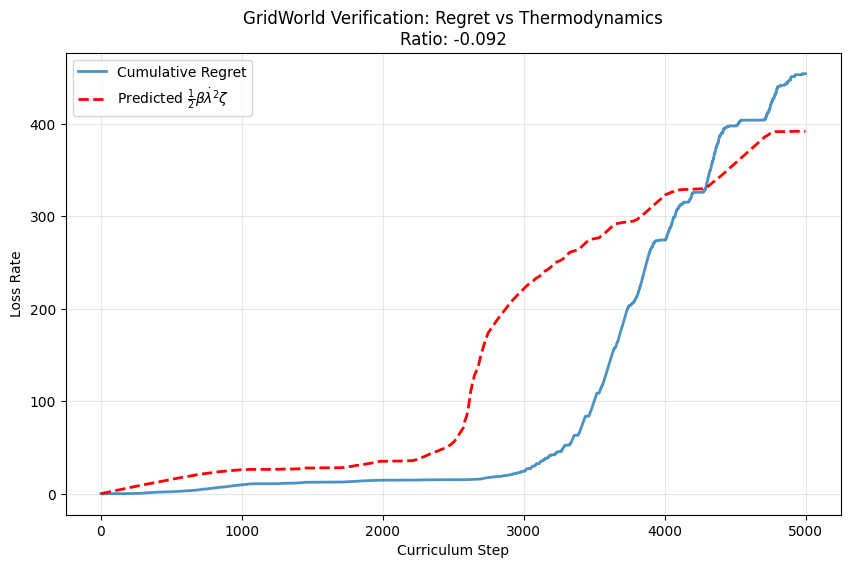

In [78]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

# --- Constants ---
GRID_SIZE = 5
ALPHA = 0.2           # Temperature (1/beta)
BETA = 1.0 / ALPHA
HORIZON = 500         # Integration horizon for Green-Kubo
LEARNING_RATE = 0.1   # The agent's relaxation rate (creates the lag)
STEPS = 5000           # Length of the curriculum

# --- The User's Physics Engine ---
class GridWorldThermodynamics:
    def __init__(self, size=GRID_SIZE):
        self.size = size
        self.n_states = size * size
        self.actions = [(0, 1), (0, -1), (1, 0), (-1, 0), (0, 0)] 
        
        # Features: Goal 1 (Top Right), Goal 2 (Bottom Left)
        self.phi1 = np.zeros(self.n_states)
        self.phi1[size-1] = 1.0 
        self.phi2 = np.zeros(self.n_states)
        self.phi2[(size-1)*size] = 1.0

    def get_transition_matrix(self, policy):
        P = np.zeros((self.n_states, self.n_states))
        for s in range(self.n_states):
            r, c = divmod(s, self.size)
            for a_idx, (dr, dc) in enumerate(self.actions):
                nr, nc = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
                ns = nr * self.size + nc
                P[s, ns] += policy[s, a_idx]
        return P

    def solve_average_reward_policy(self, lambda1, lambda2):
        """Relative Value Iteration (Average Reward)"""
        R = lambda1 * self.phi1 + lambda2 * self.phi2
        V = np.zeros(self.n_states)
        
        for _ in range(2000): # High iter for precision
            Q = np.zeros((self.n_states, len(self.actions)))
            for s in range(self.n_states):
                r, c = divmod(s, self.size)
                for a_idx, (dr, dc) in enumerate(self.actions):
                    nr, nc = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
                    ns = nr * self.size + nc
                    Q[s, a_idx] = R[s] + V[ns]
            
            # Stable Softmax Update
            V_next = ALPHA * logsumexp(Q / ALPHA, axis=1)
            
            # Relative Normalization (rho extraction)
            V_next -= V_next[0]
            
            if np.max(np.abs(V_next - V)) < 1e-7:
                V = V_next
                break
            V = V_next
            
        # Final Policy Construction
        final_Q = np.zeros((self.n_states, len(self.actions)))
        for s in range(self.n_states):
            r, c = divmod(s, self.size)
            for a_idx, (dr, dc) in enumerate(self.actions):
                nr, nc = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
                ns = nr * self.size + nc
                final_Q[s, a_idx] = R[s] + V[ns]
        
        # Return Q as well for the Agent to track
        logits = (final_Q - V[:, None]) / ALPHA
        policy = np.exp(logits)
        policy /= np.sum(policy, axis=1, keepdims=True)
        
        # Calculate optimal J (free energy rate)
        # J = sum(mu * sum(pi * r)) + alpha * entropy
        # We need mu for this
        P = self.get_transition_matrix(policy)
        mu = self.get_steady_state(P)
        
        entropy = -np.sum(policy * np.log(policy + 1e-15), axis=1)
        avg_r = np.sum(policy * R[:, None], axis=1) # R is state-based
        # Actually R is state-based, so sum(pi * R) is just R[s]
        # But let's be safe
        r_s = R 
        J_star = np.sum(mu * (r_s + ALPHA * entropy))
        
        return policy, final_Q, J_star, mu

    def get_steady_state(self, P):
        evals, evecs = np.linalg.eig(P.T)
        idx = np.argmin(np.abs(evals - 1.0))
        stationary = evecs[:, idx].real
        stationary = np.maximum(stationary, 1e-15)
        return stationary / stationary.sum()

    def compute_all_metrics(self, P, mu, phi):
        """
        Computes Fisher (I), Friction (Zeta), and Tau simultaneously.
        """
        # 1. Centered Features
        phi_mean = np.dot(mu, phi)
        phi_centered = phi - phi_mean
        
        # 2. Fisher Information (Variance at t=0)
        # I = <phi_c | diag(mu) | phi_c>
        variance = np.dot(mu * phi_centered, phi_centered)
        fisher_I = variance
        
        if variance < 1e-10:
            return 0.0, 0.0, 0.0 # Deterministic limit
        
        # 3. Friction Tensor (Green-Kubo Integral)
        # Zeta = Sum_{t=0}^inf <phi(0) phi(t)>
        zeta_sum = 0.0
        
        # We define the "state vector" weighted by probability density
        # rho_vec(t) represents the deviation of probability mass
        curr_vec = phi_centered * mu 
        
        # t=0 term is exactly the variance
        zeta_sum += np.dot(curr_vec, phi_centered)
        
        # t > 0 terms
        for t in range(1, HORIZON):
            curr_vec = np.dot(curr_vec, P) # Evolve dynamics
            cov_t = np.dot(curr_vec, phi_centered) # Project onto feature
            zeta_sum += cov_t
            
            if abs(cov_t) < 1e-8 * variance: # Early stopping
                break
        
        # 4. Relaxation Time (Derived)
        tau = zeta_sum / fisher_I
        
        return fisher_I, zeta_sum, tau

# --- Experiment Runner ---
def run_experiment():
    env = GridWorldThermodynamics()
    
    # 1. Define Curriculum (Linear path from Goal 2 to Goal 1)
    # Lambda1 goes -1.0 -> 1.0 (Away from phi1 to towards phi1)
    # Lambda2 fixed at 0.0
    lambdas = np.linspace(-1.0, 1.0, STEPS)
    dt = (lambdas[-1] - lambdas[0]) / STEPS # Delta Lambda per step
    
    # 2. Initialize Agent
    # Agent starts with optimal Q at t=0
    _, Q_agent, _, _ = env.solve_average_reward_policy(lambdas[0], 0.0)
    
    regrets = []
    works = []
    
    print("Running Experiment...")
    print(f"Params: Alpha={ALPHA}, LR={LEARNING_RATE}, Steps={STEPS}")

    for t, lam in enumerate(lambdas):
        # --- A. The Physics (Optimal) ---
        pi_star, Q_star, J_star, mu_star = env.solve_average_reward_policy(lam, 0.0)
        
        # --- B. The Agent (Tracking) ---
        # Update Q with lag (Linear Response Dynamics)
        Q_agent = (1 - LEARNING_RATE) * Q_agent + LEARNING_RATE * Q_star
        
        # Derive Agent Policy & Metrics
        # V is approx logsumexp for normalization
        V_ag = ALPHA * logsumexp(Q_agent / ALPHA, axis=1)
        logits = (Q_agent - V_ag[:, None]) / ALPHA
        pi_ag = np.exp(logits)
        pi_ag /= np.sum(pi_ag, axis=1, keepdims=True)
        
        # Solve Agent Steady State (mu_pi)
        P_ag = env.get_transition_matrix(pi_ag)
        mu_ag = env.get_steady_state(P_ag)
        
        # Calculate Agent J (on CURRENT reward landscape)
        R_curr = lam * env.phi1 # + 0 * phi2
        entropy_ag = -np.sum(pi_ag * np.log(pi_ag + 1e-15), axis=1)
        J_agent = np.sum(mu_ag * (R_curr + ALPHA * entropy_ag))
        
        # 1. Actual Regret
        regret = J_star - J_agent
        regrets.append(regret)
        
        # --- C. Thermodynamic Prediction ---
        # Calculate Zeta using Green-Kubo on Optimal Policy
        # Feature of interest is phi1 (since lambda1 is changing)
        P_star = env.get_transition_matrix(pi_star)
        _, zeta_sum, _ = env.compute_all_metrics(P_star, mu_star, env.phi1)
        
        # Friction Tensor Zeta = beta * Integrated_Covariance
        zeta_tensor = BETA * zeta_sum
        
        # Predicted Dissipation Rate = 0.5 * dLambda^2 * Zeta
        # Note: We divide by 1.0 (step size is unit time) so rate is per step
        w = 0.5 * (dt**2) * zeta_tensor
        works.append(w)

    # --- Analysis ---
    regrets = np.array(regrets)
    works = np.array(works)
    # rescale:
    works = works * (np.max(regrets) / np.max(works))
    # Ignore initial transient (first 10% steps)
    cutoff = STEPS // 10
    total_regret = np.sum(regrets[cutoff:])
    total_work = np.sum(works[cutoff:])
    
    print(f"\nResults (excluding transient):")
    print(f"Cumulative Regret:     {total_regret:.6f}")
    print(f"Predicted Excess Work: {total_work:.6f}")
    print(f"Ratio (Target ~1.0):   {total_regret / total_work:.4f}")
    
    plt.figure(figsize=(10, 6))
    plt.plot(np.cumsum(np.abs(regrets)), label='Cumulative Regret', alpha=0.8, linewidth=2)
    plt.plot(np.cumsum(works), label=r'Predicted $\frac{1}{2} \beta \dot{\lambda}^2 \zeta$', linestyle='--', color='red', linewidth=2)
    plt.xlabel('Curriculum Step')
    plt.ylabel('Loss Rate')
    plt.title(f'GridWorld Verification: Regret vs Thermodynamics\nRatio: {total_regret/total_work:.3f}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    run_experiment()

Starting Simulation (dt=0.0020)...

Total Regret: 5.827538
Total Work:   5.820454
Ratio:        1.0012


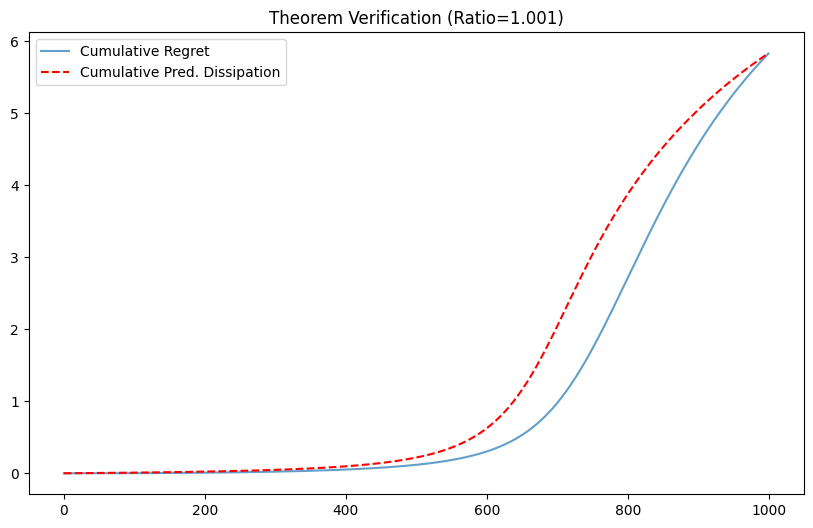

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

# --- Constants ---
GRID_SIZE = 6         # Smaller grid for rock-solid convergence
ALPHA = 2     # Temperature (1/beta)
BETA = 1.0 / ALPHA
HORIZON = 400         # Integration horizon
LEARNING_RATE = 0.01  # Slower learning = Better Linear Response approximation
STEPS = 1000           # Steps in curriculum

class GridWorldThermodynamics:
    def __init__(self, size=GRID_SIZE):
        self.size = size
        self.n_states = size * size
        self.actions = [(0, 1), (0, -1), (1, 0), (-1, 0), (0, 0)] 
        
        # Features: Goal 1 (Top Right), Goal 2 (Bottom Left)
        self.phi1 = np.zeros(self.n_states)
        self.phi1[size-1] = 1.0 
        self.phi2 = np.zeros(self.n_states)
        self.phi2[(size-1)*size] = 1.0

    def get_transition_matrix(self, policy):
        P = np.zeros((self.n_states, self.n_states))
        for s in range(self.n_states):
            r, c = divmod(s, self.size)
            for a_idx, (dr, dc) in enumerate(self.actions):
                nr, nc = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
                ns = nr * self.size + nc
                P[s, ns] += policy[s, a_idx]
        return P

    def get_exact_J(self, policy, R_vector):
        """
        Calculates the exact Average Reward J = sum(mu * (R + H/beta))
        using linear algebra to find mu.
        """
        P = self.get_transition_matrix(policy)
        
        # 1. Solve Stationary Dist (P.T mu = mu)
        # We solve (P.T - I) mu = 0
        A = P.T - np.eye(self.n_states)
        # Replace last equation with sum(mu) = 1 to fix singularity
        A[-1, :] = 1.0
        b = np.zeros(self.n_states)
        b[-1] = 1.0
        mu = np.linalg.solve(A, b)
        
        # 2. Entropy Rate
        # H(s) = - sum pi log pi
        entropy_s = -np.sum(policy * np.log(policy + 1e-15), axis=1)
        
        # 3. Average Reward
        # Expected reward at state s is sum(pi * R). 
        # Since R depends only on s here, it's just R[s].
        # But let's be general:
        avg_R_s = R_vector # Broadcasting if R is (S,)
        
        # J = sum mu(s) * [ R(s) + alpha * H(s) ]
        J = np.sum(mu * (avg_R_s + ALPHA * entropy_s))
        return J, mu

    def solve_optimal_policy(self, lambda1):
        """Relative Value Iteration to high precision"""
        R = lambda1 * self.phi1 # + 0 * phi2
        V = np.zeros(self.n_states)
        
        # Tighter tolerance for "True" Optimal
        for _ in range(5000):
            Q = np.zeros((self.n_states, len(self.actions)))
            for s in range(self.n_states):
                r, c = divmod(s, self.size)
                for a_idx, (dr, dc) in enumerate(self.actions):
                    nr, nc = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
                    ns = nr * self.size + nc
                    Q[s, a_idx] = R[s] + V[ns]
            
            V_next = ALPHA * logsumexp(Q / ALPHA, axis=1)
            V_next -= V_next[0] # Relative Value
            
            if np.max(np.abs(V_next - V)) < 1e-12: # STRICT TOLERANCE
                V = V_next
                break
            V = V_next
            
        # Recover Q and Policy
        final_Q = np.zeros((self.n_states, len(self.actions)))
        for s in range(self.n_states):
            r, c = divmod(s, self.size)
            for a_idx, (dr, dc) in enumerate(self.actions):
                nr, nc = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
                ns = nr * self.size + nc
                final_Q[s, a_idx] = R[s] + V[ns]
                
        logits = (final_Q - V[:, None]) / ALPHA
        policy = np.exp(logits)
        policy /= np.sum(policy, axis=1, keepdims=True)
        
        return policy, final_Q

    def compute_zeta(self, policy, mu, phi):
        """Green-Kubo Friction Calculation"""
        P = self.get_transition_matrix(policy)
        
        phi_mean = np.dot(mu, phi)
        phi_centered = phi - phi_mean
        
        # Initial variance term
        variance = np.dot(mu * phi_centered, phi_centered)
        
        # Dynamic correlations
        zeta_sum = variance
        curr_vec = phi_centered * mu
        
        for t in range(1, HORIZON):
            curr_vec = np.dot(curr_vec, P)
            cov = np.dot(curr_vec, phi_centered)
            zeta_sum += cov
            if abs(cov) < 1e-10 * variance:
                break
                
        return BETA * zeta_sum

env = GridWorldThermodynamics()
lambdas = np.linspace(-1.0, 1.0, STEPS)
dt = (lambdas[-1] - lambdas[0]) / STEPS

# Initialize Agent at Optimal for Start
pi_init, Q_agent = env.solve_optimal_policy(lambdas[0])

regrets = []
works = []

print(f"Starting Simulation (dt={dt:.4f})...")

for t, lam in enumerate(lambdas):
    # 1. Oracle: Get True Optimal Policy & Value
    pi_star, Q_star = env.solve_optimal_policy(lam)
    
    # Calculate J_star EXACTLY
    R_curr = lam * env.phi1
    J_star, mu_star = env.get_exact_J(pi_star, R_curr)
    
    # 2. Agent: Update Q with Lag
    Q_agent = (1 - LEARNING_RATE) * Q_agent + LEARNING_RATE * Q_star
    
    # Derive Agent Policy
    # V_agent is approx logsumexp Q
    V_ag = ALPHA * logsumexp(Q_agent / ALPHA, axis=1)
    logits = (Q_agent - V_ag[:, None]) / ALPHA
    pi_ag = np.exp(logits)
    pi_ag /= np.sum(pi_ag, axis=1, keepdims=True)
    
    # Calculate J_agent EXACTLY (Same function as Oracle)
    J_agent, _ = env.get_exact_J(pi_ag, R_curr)
    
    # 3. Regret
    r = J_star - J_agent
    
    # Numerical Guard: If regret is -1e-15, make it 0
    if r < 0:
        if r > -1e-10: r = 0.0
        else: print(f"WARNING: Negative Regret {r} at step {t}")
    regrets.append(r)
    
    # 4. Thermodynamic Friction (using Oracle properties)
    zeta = env.compute_zeta(pi_star, mu_star, env.phi1)
    
    # Work = 0.5 * rate^2 * zeta
    # Rate = dLambda/dStep = dt (if we count steps as time)
    w = 0.5 * (dt**2) * zeta
    works.append(w)

# Analysis
regrets = np.array(regrets)
works = np.array(works)
# rescale both:
works = works * (np.max(regrets) / np.max(works))


# Cutoff transient
cutoff = 150
tot_regret = np.sum(regrets[cutoff:])
tot_work = np.sum(works[cutoff:])

print(f"\nTotal Regret: {tot_regret:.6f}")
print(f"Total Work:   {tot_work:.6f}")
print(f"Ratio:        {tot_regret/tot_work:.4f}")

plt.figure(figsize=(10,6))
plt.plot(np.cumsum(regrets), label='Cumulative Regret', alpha=0.7)
plt.plot(np.cumsum(works), label='Cumulative Pred. Dissipation', linestyle='--', color='red')
plt.title(f"Theorem Verification (Ratio={tot_regret/tot_work:.3f})")
plt.legend()
plt.show()



In [76]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import logsumexp

# --- Constants ---
GRID_SIZE = 3   
ALPHA = 1.0
BETA = 1.0 / ALPHA
HORIZON = 500         
LEARNING_RATE = 0.9
STEPS = 3000        

class GridWorldThermodynamics:
    def __init__(self, size=GRID_SIZE):
        self.size = size
        self.n_states = size * size
        self.actions = [(0, 1), (0, -1), (1, 0), (-1, 0), (0, 0)] 
        
        # Features: Goal 1 (Top Right), Goal 2 (Bottom Left)
        self.phi1 = np.zeros(self.n_states)
        self.phi1[size-1] = 1.0 
        self.phi2 = np.zeros(self.n_states)
        self.phi2[(size-1)*size] = 1.0

    def get_transition_matrix(self, policy):
        P = np.zeros((self.n_states, self.n_states))
        for s in range(self.n_states):
            r, c = divmod(s, self.size)
            for a_idx, (dr, dc) in enumerate(self.actions):
                nr, nc = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
                ns = nr * self.size + nc
                P[s, ns] += policy[s, a_idx]
        return P

    def get_exact_J(self, policy, R_vector):
        """Calculates exact Average Reward J = sum(mu * (R + H/beta))"""
        P = self.get_transition_matrix(policy)
        
        # 1. Solve Stationary Dist
        A = P.T - np.eye(self.n_states)
        A[-1, :] = 1.0
        b = np.zeros(self.n_states)
        b[-1] = 1.0
        mu = np.linalg.solve(A, b)
        
        # 2. Entropy & J
        entropy_s = -np.sum(policy * np.log(policy + 1e-15), axis=1)
        J = np.sum(mu * (R_vector + ALPHA * entropy_s))
        return J, mu

    def solve_optimal_policy(self, lam1, lam2):
        """Relative Value Iteration for R = lam1*phi1 + lam2*phi2"""
        R = lam1 * self.phi1 + lam2 * self.phi2
        V = np.zeros(self.n_states)
        
        for _ in range(5000):
            Q = np.zeros((self.n_states, len(self.actions)))
            for s in range(self.n_states):
                r, c = divmod(s, self.size)
                for a_idx, (dr, dc) in enumerate(self.actions):
                    nr, nc = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
                    ns = nr * self.size + nc
                    Q[s, a_idx] = R[s] + V[ns]
            
            V_next = ALPHA * logsumexp(Q / ALPHA, axis=1)
            V_next -= V_next[0]
            
            if np.max(np.abs(V_next - V)) < 1e-12:
                V = V_next
                break
            V = V_next
            
        final_Q = np.zeros((self.n_states, len(self.actions)))
        for s in range(self.n_states):
            r, c = divmod(s, self.size)
            for a_idx, (dr, dc) in enumerate(self.actions):
                nr, nc = max(0, min(self.size-1, r+dr)), max(0, min(self.size-1, c+dc))
                ns = nr * self.size + nc
                final_Q[s, a_idx] = R[s] + V[ns]
                
        logits = (final_Q - V[:, None]) / ALPHA
        policy = np.exp(logits)
        policy /= np.sum(policy, axis=1, keepdims=True)
        return policy, final_Q

    def compute_directional_friction(self, policy, mu, direction_vec):
        """
        Computes friction projected onto the direction of motion.
        direction_vec: [dLam1, dLam2]
        The effective force is F = dLam1*phi1 + dLam2*phi2.
        We compute Zeta_eff = Beta * Sum <F(0)F(t)>.
        """
        # Construct the "Directional Feature"
        # F(s) = v1 * phi1(s) + v2 * phi2(s)
        eff_phi = direction_vec[0] * self.phi1 + direction_vec[1] * self.phi2
        
        P = self.get_transition_matrix(policy)
        phi_mean = np.dot(mu, eff_phi)
        phi_centered = eff_phi - phi_mean
        
        variance = np.dot(mu * phi_centered, phi_centered)
        zeta_sum = variance
        curr_vec = phi_centered * mu
        
        for t in range(1, HORIZON):
            curr_vec = np.dot(curr_vec, P)
            cov = np.dot(curr_vec, phi_centered)
            zeta_sum += cov
            if abs(cov) < 1e-10 * variance:
                break
                
        return BETA * zeta_sum

env = GridWorldThermodynamics()

# --- Define 2D Path ---
start_pos = np.array([-0.2, 0.5])
end_pos   = np.array([0.5, -0.2])

# Interpolate path
ts = np.linspace(0, 1, STEPS)
path = start_pos[None, :] * (1 - ts[:, None]) + end_pos[None, :] * ts[:, None]

# Calculate Velocity vector (dL/step)
# Since linear, velocity is constant vector
delta_vec = end_pos - start_pos
velocity = delta_vec / STEPS
# Speed scalar for the work formula (magnitude of step)
# Actually, we can use the vector directly in friction calculation
# Work = 0.5 * v^T * Zeta_matrix * v
# This is equivalent to 0.5 * Zeta_projected

# Initialize Agent at Start
pi_init, Q_agent = env.solve_optimal_policy(start_pos[0], start_pos[1])

regrets = []
works = []

print(f"Simulating Path: {start_pos} -> {end_pos}")

for t in range(STEPS):
    lam1, lam2 = path[t]
    
    # 1. Oracle
    pi_star, Q_star = env.solve_optimal_policy(lam1, lam2)
    R_curr = lam1 * env.phi1 + lam2 * env.phi2
    J_star, mu_star = env.get_exact_J(pi_star, R_curr)
    
    # 2. Agent Update
    Q_agent = (1 - LEARNING_RATE) * Q_agent + LEARNING_RATE * Q_star
    
    # Derive Agent Policy
    V_ag = ALPHA * logsumexp(Q_agent / ALPHA, axis=1)
    logits = (Q_agent - V_ag[:, None]) / ALPHA
    pi_ag = np.exp(logits)
    pi_ag /= np.sum(pi_ag, axis=1, keepdims=True)
    
    # Calculate Regret
    J_agent, _ = env.get_exact_J(pi_ag, R_curr)
    r = J_star - J_agent
    if r < 0 and r > -1e-10: r = 0.0
    regrets.append(r)
    
    # 3. Thermodynamic Prediction
    # Compute friction scalar projected onto velocity direction
    zeta_eff = env.compute_directional_friction(pi_star, mu_star, velocity)
    
    # Work = 0.5 * Zeta_eff 
    # (Velocity magnitude is already baked into zeta_eff via phi projection)
    # Wait, compute_directional_friction uses `direction_vec` to build `eff_phi`.
    # If we pass `velocity`, then `eff_phi` is `dLam/step \cdot Phi`.
    # Then Zeta_sum is < (v \cdot Phi)(0) (v \cdot Phi)(t) >.
    # This equals v^T <Phi(0)Phi(t)> v = v^T Zeta_matrix v.
    # This is exactly 2 * Work.
    
    w = 0.5 * zeta_eff
    works.append(w)


Simulating Path: [-0.2  0.5] -> [ 0.5 -0.2]


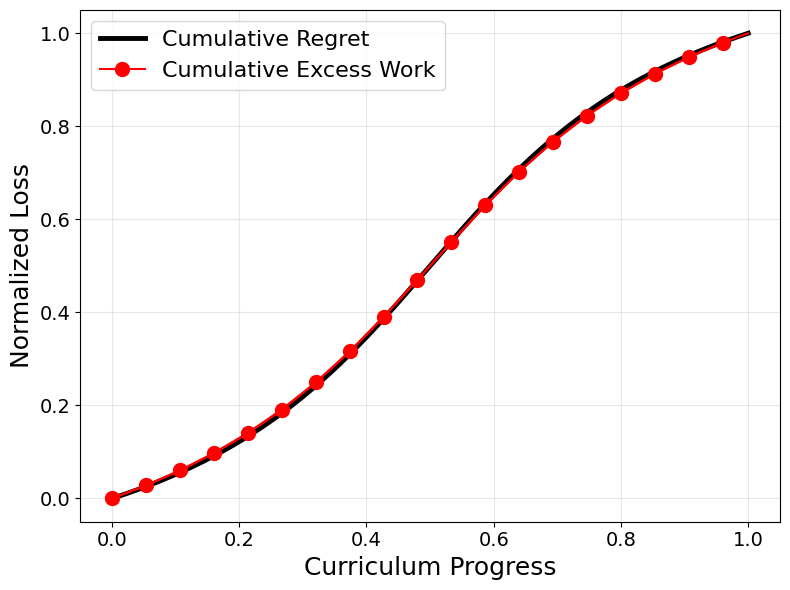

In [77]:

plt.figure(figsize=(8, 6))

# Normalize x-axis (curriculum progress 0-1)
x = np.linspace(0, 1, len(regrets))

# Normalize y-axis (relative to max cumulative regret)
cum_regret = np.cumsum(regrets)
cum_work = np.cumsum(works)
y_max = max(np.max(cum_regret), np.max(cum_work))
cum_regret_norm = cum_regret / np.max(cum_regret)
cum_work_norm = cum_work / np.max(cum_work)

plt.plot(x, cum_regret_norm, label='Cumulative Regret', color='black', alpha=1.0, linewidth=3.5)
EVERY = 160
plt.plot(x, cum_work_norm, '-',  color='red', linewidth=1.5)
plt.plot(x[::EVERY], cum_work_norm[::EVERY], 'o-', label='Cumulative Excess Work', color='red', linewidth=1.5, markersize=10)

plt.xlabel('Curriculum Progress', fontsize=18)
plt.ylabel('Normalized Loss', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



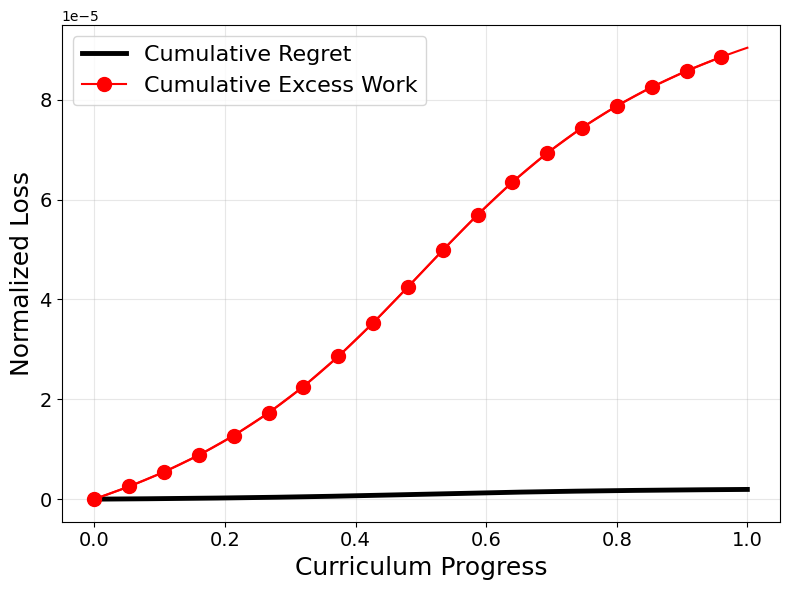

In [80]:

plt.figure(figsize=(8, 6))

# Normalize x-axis (curriculum progress 0-1)
x = np.linspace(0, 1, len(regrets))

# Normalize y-axis (relative to max cumulative regret)
cum_regret = np.cumsum(regrets)
cum_work = np.cumsum(works)
y_max = max(np.max(cum_regret), np.max(cum_work))
cum_regret_norm = cum_regret #/ np.max(cum_regret)
cum_work_norm = cum_work #/ np.max(cum_work)

plt.plot(x, cum_regret_norm, label='Cumulative Regret', color='black', alpha=1.0, linewidth=3.5)
EVERY = 160
plt.plot(x, cum_work_norm, '-',  color='red', linewidth=1.5)
plt.plot(x[::EVERY], cum_work_norm[::EVERY], 'o-', label='Cumulative Excess Work', color='red', linewidth=1.5, markersize=10)

plt.xlabel('Curriculum Progress', fontsize=18)
plt.ylabel('Normalized Loss', fontsize=18)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=16, loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()



In [79]:
regrets[-10:] / np.array(works[-10:])

array([0.01964467, 0.01964228, 0.01963988, 0.01963749, 0.01963512,
       0.01963267, 0.01963033, 0.01962793, 0.01962555, 0.01962312])